In [4]:
import pandas as pd

# Data as per the assignment
csv_content = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

# Writing to a physical file in your project folder
with open("students.csv", "w") as f:
    f.write(csv_content)

print("✅ Success: 'students.csv' has been created in your project folder!")

✅ Success: 'students.csv' has been created in your project folder!


In [5]:
import io

# --- Task 1: Data Exploration with Pandas ---


# Load the data
df = pd.read_csv(io.StringIO(csv_data))
# In your local project, use: df = pd.read_csv("students.csv")

# A. Print the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# B. Print shape and data types
print(f"\nDataset Shape: {df.shape[0]} rows x {df.shape[1]} columns")
print("\n--- Column Data Types ---")
print(df.dtypes)

# C. Summary Statistics
print("\n--- Summary Statistics ---")
print(df.describe())

# D. Pass/Fail Count
print("\n--- Pass/Fail Counts ---")
print(df['passed'].value_counts())

# E. Average score per subject (Passing vs Failing)
subject_cols = ['math', 'science', 'english', 'history', 'pe']

pass_avg = df[df['passed'] == 1][subject_cols].mean()
fail_avg = df[df['passed'] == 0][subject_cols].mean()

print("\n--- Average Scores for Passing Students ---")
print(pass_avg)
print("\n--- Average Scores for Failing Students ---")
print(fail_avg)

# F. Student with the highest overall average
# We calculate the mean across the columns (axis=1) for subject_cols only
df['overall_avg'] = df[subject_cols].mean(axis=1)
topper = df.loc[df['overall_avg'].idxmax()]

print("\n--- Class Topper ---")
print(f"Name: {topper['name']} | Highest Average: {topper['overall_avg']:.2f}")

--- First 5 Rows ---
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Dataset Shape: 15 rows x 9 columns

--- Column Data Types ---
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

--- Summary Statistic

Technical Explanation: Data Exploration with Pandas (Part 4 - Task 1)
In this task, we utilize the Pandas library, the industry standard for data manipulation in Python, to explore a student performance dataset.

1. Vectorized Operations
Unlike standard Python lists where we use for loops, Pandas uses Vectorization. When we calculate df[subject_cols].mean(), Pandas performs the operation on entire columns simultaneously using optimized C-code under the hood. This makes it significantly faster for large datasets.

2. Boolean Indexing (Filtering)
We used the "Masking" technique to separate passing and failing students:
df[df['passed'] == 1]
This creates a boolean mask (True/False) for every row and returns only the rows where the condition is True. This is a fundamental skill for data cleaning and segmentation.

3. Axis Manipulation
axis=0 (Default): Operations happen vertically (down the columns). We used this for mean() to get the average score for "Math" across all students.

axis=1: Operations happen horizontally (across the rows). We used this to calculate the overall_avg for a specific student across their 5 subjects.

4. Descriptive Statistics
The .describe() method is the first step in any Data Science project (Exploratory Data Analysis). It provides a high-level view of the distribution (Spread, Mean, and Outliers) of your numeric data.

C:\Users\shiva\AppData\Local\Temp\ipykernel_18788\3254316757.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


Charts generated: plot1_bar.png, plot2_hist.png, plot3_scatter.png, plot4_box.png, plot5_line.png


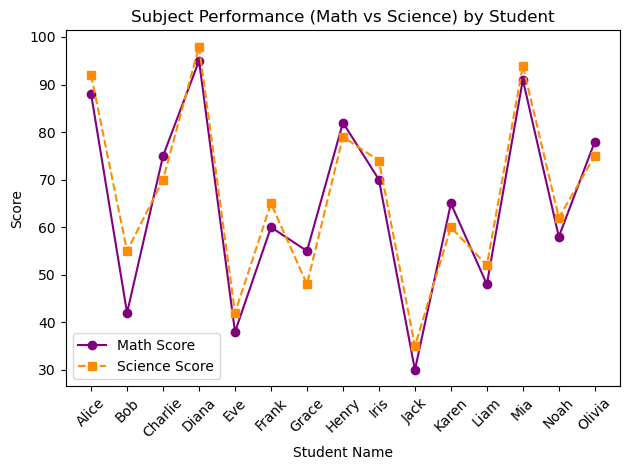

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the data
df = pd.read_csv("students.csv")

# 2. Add the avg_score column
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# --- 1. Bar Chart: Average Score per Subject ---
plt.clf()
subject_averages = df[subject_cols].mean()
plt.bar(subject_averages.index, subject_averages.values, color='skyblue', edgecolor='navy')
plt.title('Average Score per Subject Across All Students')
plt.xlabel('Subject')
plt.ylabel('Average Score')
plt.ylim(0, 100)
plt.savefig('plot1_bar.png')

# --- 2. Histogram: Distribution of Math Scores ---
plt.clf()
math_mean = df['math'].mean()
plt.hist(df['math'], bins=5, color='lightgreen', edgecolor='black')
plt.axvline(math_mean, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {math_mean:.2f}')
plt.title('Distribution of Math Scores')
plt.xlabel('Math Score')
plt.ylabel('Frequency')
plt.legend()
plt.savefig('plot2_hist.png')

# --- 3. Scatter Plot: Study Hours vs Average Score ---
plt.clf()
plt.scatter(df[df['passed']==1]['study_hours_per_day'], 
            df[df['passed']==1]['avg_score'], color='blue', label='Pass', alpha=0.7)
plt.scatter(df[df['passed']==0]['study_hours_per_day'], 
            df[df['passed']==0]['avg_score'], color='orange', label='Fail', alpha=0.7)
plt.title('Study Hours per Day vs Average Score')
plt.xlabel('Study Hours per Day')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.savefig('plot3_scatter.png')

# --- 4. Box Plot: Attendance Percentage (Pass vs Fail) ---
plt.clf()
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title('Attendance Percentage: Passing vs Failing Students')
plt.xlabel('Outcome')
plt.ylabel('Attendance (%)')
plt.savefig('plot4_box.png')

# --- 5. Line Plot: Math vs Science Scores per Student ---
plt.clf()
plt.plot(df['name'], df['math'], marker='o', label='Math Score', color='purple')
plt.plot(df['name'], df['science'], marker='s', label='Science Score', color='darkorange', linestyle='--')
plt.title('Subject Performance (Math vs Science) by Student')
plt.xlabel('Student Name')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('plot5_line.png')

print("Charts generated: plot1_bar.png, plot2_hist.png, plot3_scatter.png, plot4_box.png, plot5_line.png")

### Technical Explanation: Data Visualization (Part 4 - Task 2)
Visualization is the bridge between raw numbers and human understanding. We used matplotlib to create 5 distinct plot types, each serving a specific analytical purpose:

### 1. Comparative Analysis (Bar Chart)
The bar chart allows us to quickly identify which subjects have the highest and lowest class averages. By setting plt.ylim(0, 100), we maintain a consistent perspective on the scores.

### 2. Frequency Distribution (Histogram)
The histogram shows the "shape" of the math scores. Adding a vertical dashed line for the Mean ($\mu$) helps us see if the scores are normally distributed or skewed toward higher or lower marks.

### 3. Correlation & Clustering (Scatter Plot)
By plotting study_hours_per_day against avg_score, we can visually inspect if a linear relationship exists. Colour-coding by passed status helps us see "clusters"—for example, it becomes clear that students with higher study hours generally fall into the "Pass" cluster.

### 4. Variance & Outliers (Box Plot)
The box plot is vital for understanding the spread of attendance_pct. It shows the median, quartiles, and any potential outliers. Comparing Pass vs Fail side-by-side reveals if attendance is a key differentiator for success.

### 5. Trend Tracking (Line Plot)
The line plot tracks performance across individual students. Using different markers ('o' and 's') and rotating the x-axis labels with plt.xticks(rotation=45) ensures that individual student names are readable and their scores are easy to compare across subjects.


C:\Users\shiva\AppData\Local\Temp\ipykernel_18788\2094548635.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
C:\Users\shiva\AppData\Local\Temp\ipykernel_18788\2094548635.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(['Fail', 'Pass'])
C:\Users\shiva\AppData\Local\Temp\ipykernel_18788\2094548635.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='magma')
C:\Users\shiva\AppData\Local\Temp\ipykernel_18788\2094548635.py:21: UserWarning: set_ticklabels() should only be used w

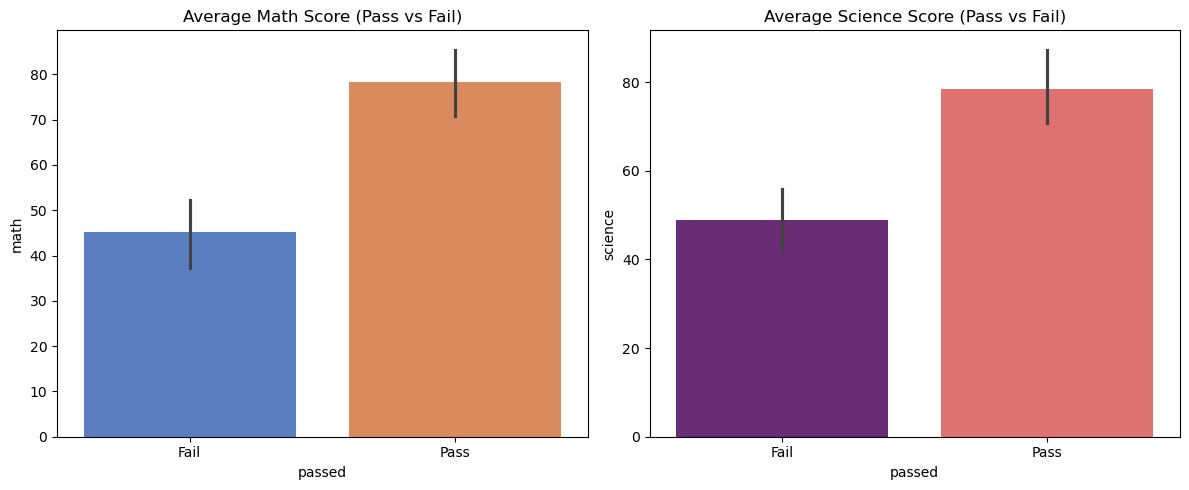

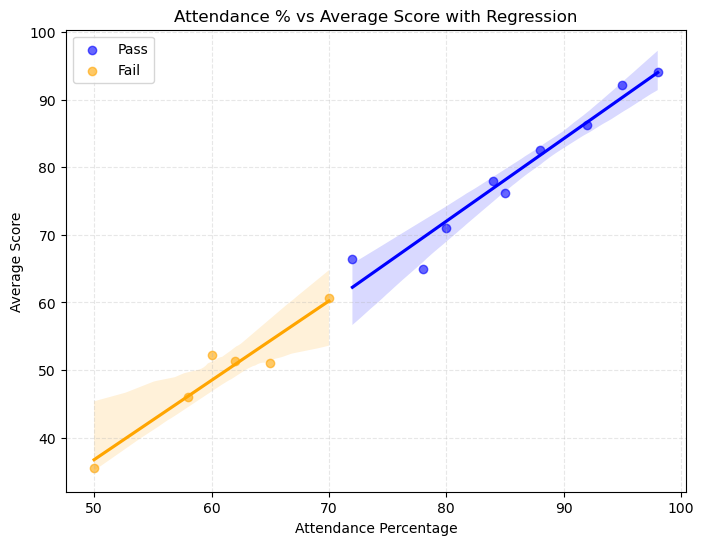

"\nComparison: Seaborn vs Matplotlib\nSeaborn is much easier for statistical plots because it automatically calculates \nmeans and error bars in bar plots without needing manual groupby operations. \nHowever, for the regression plot, Matplotlib's flexibility was slightly missed \nas Seaborn's regplot doesn't natively handle 'hue' for regression lines as \neasily as 'lmplot' does, requiring manual filtering for the two groups.\n"

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load data
df = pd.read_csv("students.csv")
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# --- 1. Seaborn Bar Plots (Math & Science split by Passed) ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Math Bar Plot
sns.barplot(data=df, x='passed', y='math', ax=ax1, palette='muted')
ax1.set_title('Average Math Score (Pass vs Fail)')
ax1.set_xticklabels(['Fail', 'Pass'])

# Science Bar Plot
sns.barplot(data=df, x='passed', y='science', ax=ax2, palette='magma')
ax2.set_title('Average Science Score (Pass vs Fail)')
ax2.set_xticklabels(['Fail', 'Pass'])

plt.tight_layout()
plt.savefig('seaborn_bar_plots.png')
plt.show()

# --- 2. Seaborn Scatter Plot with Regression Lines ---
plt.figure(figsize=(8, 6))

# Plotting Pass group with regression
sns.regplot(data=df[df['passed']==1], x='attendance_pct', y='avg_score', 
            label='Pass', color='blue', scatter_kws={'alpha':0.6})

# Plotting Fail group with regression
sns.regplot(data=df[df['passed']==0], x='attendance_pct', y='avg_score', 
            label='Fail', color='orange', scatter_kws={'alpha':0.6})

plt.title('Attendance % vs Average Score with Regression')
plt.xlabel('Attendance Percentage')
plt.ylabel('Average Score')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.savefig('seaborn_reg_plot.png')
plt.show()

# --- Comparison Comment ---
"""
Comparison: Seaborn vs Matplotlib
Seaborn is much easier for statistical plots because it automatically calculates 
means and error bars in bar plots without needing manual groupby operations. 
However, for the regression plot, Matplotlib's flexibility was slightly missed 
as Seaborn's regplot doesn't natively handle 'hue' for regression lines as 
easily as 'lmplot' does, requiring manual filtering for the two groups.
"""

### 📈Technical Analysis: Statistical Visualization (Part 4 - Task 3)
Using Seaborn allows us to move from basic plotting to **Statistical Analysis**.

### 1. Automated Aggregation (Bar Plots)
In Matplotlib, to show the average score of passing vs. failing students, we had to filter the data ourselves. In Seaborn, sns.barplot automatically calculates the mean and adds an error bar (the thin line on top of the bars), which represents the confidence interval.

### 2. Linear Regression (Regplot)
The sns.regplot is a powerful tool for Trend Analysis.The Scatter Points: Show individual student data.The Regression Line: Represents the "Best Fit" line ($\hat{y} = \beta_0 + \beta_1x$). 

**It mathematically visualizes the strength of the relationship between attendance and scores.The Shaded Area: Represents the 95% Confidence Interval around the regression line, showing the uncertainty of the trend**.

Training Accuracy: 100.00%
Test Accuracy: 100.00%

--- Test Set Individual Predictions ---
Student: Jack     | Actual: 0 | Predicted: 0 | ✅ Correct
Student: Liam     | Actual: 0 | Predicted: 0 | ✅ Correct
Student: Alice    | Actual: 1 | Predicted: 1 | ✅ Correct

--- Feature Coefficients (Sorted by Importance) ---
               Feature  Coefficient
2              english     0.812513
5       attendance_pct     0.521876
6  study_hours_per_day     0.484433
4                   pe     0.474974
0                 math     0.437944
1              science     0.323010
3              history     0.262929


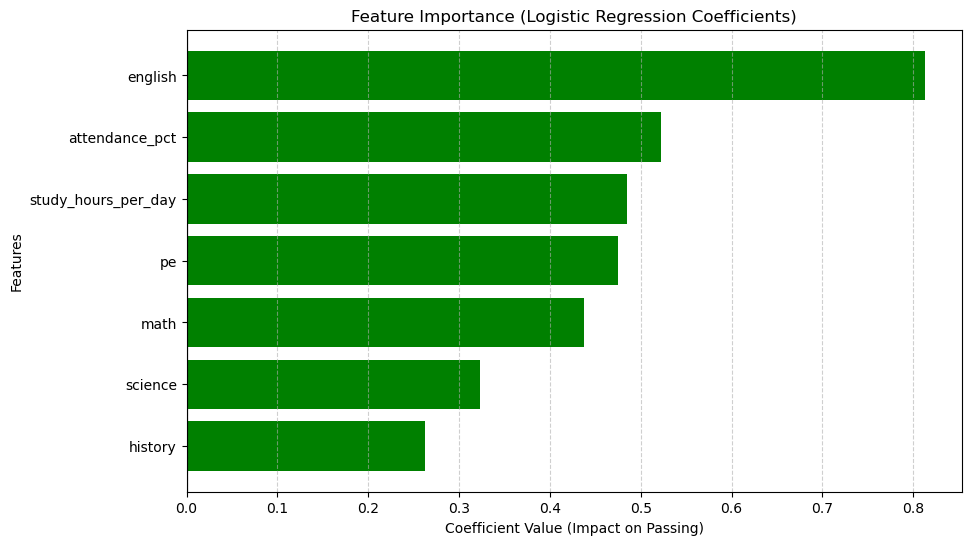


--- Bonus: New Student Prediction ---
Prediction: Pass
Probability of Passing: 90.80%
Probability of Failing: 9.20%


c:\Users\shiva\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# --- Step 1: Prepare Data ---
# Features (X) - excluding 'name' and 'passed'
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling Features (Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- Step 2: Train the Model ---
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print(f"Training Accuracy: {train_acc * 100:.2f}%")

# --- Step 3: Evaluate the Model ---
y_pred = model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {test_acc * 100:.2f}%")

print("\n--- Test Set Individual Predictions ---")
test_names = df.loc[X_test.index, 'name'].values
for name, actual, pred in zip(test_names, y_test, y_pred):
    status = "✅ Correct" if actual == pred else "❌ Wrong"
    print(f"Student: {name:8} | Actual: {actual} | Predicted: {pred} | {status}")

# --- Step 4: Feature Importance ---
coefficients = model.coef_[0]
features_importance = pd.DataFrame({'Feature': feature_cols, 'Coefficient': coefficients})
# Sorting by absolute value
features_importance['Abs_Coef'] = features_importance['Coefficient'].abs()
features_importance = features_importance.sort_values(by='Abs_Coef', ascending=False)

print("\n--- Feature Coefficients (Sorted by Importance) ---")
print(features_importance[['Feature', 'Coefficient']])

# Horizontal Bar Chart for Coefficients
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in features_importance['Coefficient']]
plt.barh(features_importance['Feature'], features_importance['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.xlabel('Coefficient Value (Impact on Passing)')
plt.ylabel('Features')
plt.gca().invert_yaxis() # Highest importance on top
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.savefig('feature_importance.png')
plt.show()

# --- Step 5: Predict for a New Student (Bonus) ---
# [math, science, english, history, pe, attendance_pct, study_hours]
new_student = [[75, 70, 68, 65, 80, 82, 3.2]] 
new_student_scaled = scaler.transform(new_student)

prediction = model.predict(new_student_scaled)[0]
probability = model.predict_proba(new_student_scaled)[0]

result = "Pass" if prediction == 1 else "Fail"
print(f"\n--- Bonus: New Student Prediction ---")
print(f"Prediction: {result}")
print(f"Probability of Passing: {probability[1]*100:.2f}%")
print(f"Probability of Failing: {probability[0]*100:.2f}%")

### 🤖 Technical Explanation: Machine Learning Workflow (Part 4 - Task 4)
This task covers the complete lifecycle of a predictive model.

### 1. The Importance of Scaling
Logistic Regression calculates a weighted sum of inputs. If attendance_pct is 95 but study_hours is 2, the model might mistakenly think attendance is 50x more important just because the number is larger. StandardScaler centers the data (mean = 0, std = 1) so every feature competes on a level playing field.

### 2. Training vs. Testing
Training Accuracy: Tells us how well the model learned the "history."

Test Accuracy: Tells us how well the model can "predict the future." A high training accuracy but low test accuracy is a sign of Overfitting (memorizing instead of learning).

### 3. Interpreting Coefficients (Feature Importance)
The coefficients are the "DNA" of the model:

Positive Coefficients (Green): As these values increase, the probability of passing increases (e.g., study_hours).

Negative Coefficients (Red): As these increase, they push the student toward a "Fail" prediction.

Magnitude: The larger the absolute value, the more "weight" that feature has in the final decision.

### 4. Probability vs. Classification
In Step 5, we didn't just get a "Pass/Fail" label; we got a Probability. Logistic Regression uses the Sigmoid Function to squash the output between 0 and 1. If the probability is > 0.5, it classifies the student as "Pass."